# Stress Dataset — EDA & Data Preparation
## Group 6 | IIT Madras | BSDA4001 — Milestone 2

**Source:** Supplementary material from published paper on physiological stress detection  
**Datasets:** SWELL-KW + WESAD (Wearable Stress and Affect Detection)  
**Signals:** EDA (Electrodermal Activity / Galvanic Skin Response) + HRV (Heart Rate Variability)  

### Dataset Comparison
| Property | SWELL-KW | WESAD |
|---|---|---|
| Subjects | 20 (IDs 1–25, excl. 8,11,14,15,23) | 14 (IDs 2–17, excl. 5,12) |
| Condition labels | 0=Neutral, 1=Time pressure, 2=Interruption | 0=No stress (baseline), 1=Stress |
| Task type | 3-class classification | Binary classification |
| Regression target | `NasaTLX` (NASA Task Load Index, 0–100) | `SSSQ` (Stress Self-Questionnaire) |
| EDA features | 58 engineered | 103 engineered |

### Physiological Signals
- **EDA (Electrodermal Activity):** Skin conductance — rises with sympathetic nervous system arousal (stress). Features include mean, peaks (APSC/INSC), onset latency, and many statistical transforms (log, sqrt, Yeo-Johnson, Box-Cox)
- **HRV (Heart Rate Variability):** R-R interval statistics — depressed HRV is a biomarker of chronic stress. Features include RMSSD, SDNN, frequency-domain measures, and transforms

### Cross-Validation Strategy
**Leave-One-Subject-Out (LOSO)** — the standard for person-independent stress detection:  
- Train on N−1 subjects, test on 1 subject, rotate
- No global train/test split — full data is saved with subject IDs for LOSO modeling

### Model Types (from paper)
- **Generic:** Population model, no personalization
- **Calibration:** Generic model fine-tuned with small samples from target subject  
- **Person-specific:** Trained and tested on same subject (LOO-CV within subject)

## Section 1 — Import Libraries

In [1]:
import os
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import f_oneway, mannwhitneyu, kruskal
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.inspection import permutation_importance
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("tab10")

print("✓ Libraries loaded")

✓ Libraries loaded


## Section 2 — Paths & Constants

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
BASE      = r"e:\Group-6-DS-and-AI-Lab-Project\Stress datasets\tac-sup-material\tac-sup-material"
DATA_DIR  = os.path.join(BASE, "dataset")
RANKS_DIR = os.path.join(BASE, "results", "feature-ranks")
OUT_DIR   = r"e:\Group-6-DS-and-AI-Lab-Project\processed_data\stress"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Dataset constants ──────────────────────────────────────────────────────────
DATASETS = ["swell", "wesad"]
SIGNALS  = ["eda", "hrv"]

# Subject IDs (from original paper — some excluded due to data quality)
SUBJECTS = {
    "swell" : [x for x in range(1, 26)  if x not in [8, 11, 14, 15, 23]],  # 20 subjects
    "wesad" : [x for x in range(2, 18)  if x not in [5, 12]],               # 14 subjects
}

# Subject ID column name (WESAD uses a space!)
SUBJ_COL = {
    "swell": "subject_id",
    "wesad": "subject id",
}

# Condition labels
CONDITION_LABELS = {
    "swell": {0: "Neutral", 1: "Time pressure", 2: "Interruption"},
    "wesad": {0: "No stress",  1: "Stress"},
}

# Regression target column
REG_TARGET = {
    "swell": "NasaTLX",
    "wesad": "SSSQ",
}

# Top N features to select (from pre-computed feature ranks)
TOP_N_FEATS = {
    ("swell", "eda"): 46,
    ("swell", "hrv"): 75,
    ("wesad", "eda"): 45,
    ("wesad", "hrv"): 40,
}

print("=" * 52)
print("  Stress Dataset Configuration")
print("=" * 52)
for ds in DATASETS:
    print(f"  {ds.upper():<8} — {len(SUBJECTS[ds])} subjects | target: {REG_TARGET[ds]}")
print(f"  Signals  — {SIGNALS}")
print(f"  Output   — {OUT_DIR}")

  Stress Dataset Configuration
  SWELL    — 20 subjects | target: NasaTLX
  WESAD    — 14 subjects | target: SSSQ
  Signals  — ['eda', 'hrv']
  Output   — e:\Group-6-DS-and-AI-Lab-Project\processed_data


## Section 3 — Load All Data Files

Each dataset×signal combination has three pre-split CSV files:
- `generic.csv` — population-level training data (used for generic model)
- `calibration.csv` — small calibration samples per new subject (fine-tuning)
- `test.csv` — held-out test set

We concatenate all three for EDA purposes (full data view), then keep the splits for modeling.

In [3]:
def load_signal_data(dataset: str, signal: str) -> dict:
    """
    Load generic/calibration/test CSVs for one dataset×signal combination.
    Returns dict with keys: 'generic', 'calibration', 'test', 'all'.
    """
    result = {}
    base = os.path.join(DATA_DIR, signal, dataset)
    for split_name in ["generic", "calibration", "test"]:
        fpath = os.path.join(base, f"{split_name}.csv")
        try:
            df = pd.read_csv(fpath)
            df["_split"] = split_name
            result[split_name] = df
            print(f"  ✓ {dataset}/{signal}/{split_name}.csv  → {df.shape}")
        except Exception as e:
            print(f"  ✗ {dataset}/{signal}/{split_name}.csv  → {e}")
            result[split_name] = None

    frames = [v for v in result.values() if v is not None and isinstance(v, pd.DataFrame)]
    result["all"] = pd.concat(frames, ignore_index=True) if frames else None
    return result


print("Loading all dataset × signal combinations ...\n")

# Main data store: data[dataset][signal] = dict
DATA = {}
for ds in DATASETS:
    DATA[ds] = {}
    for sig in SIGNALS:
        print(f"── {ds.upper()} / {sig.upper()} ──")
        DATA[ds][sig] = load_signal_data(ds, sig)
        print()

print("✓ All files loaded")

Loading all dataset × signal combinations ...

── SWELL / EDA ──
  ✓ swell/eda/generic.csv  → (42197, 62)
  ✓ swell/eda/calibration.csv  → (4772, 62)
  ✓ swell/eda/test.csv  → (4772, 62)

── SWELL / HRV ──
  ✓ swell/hrv/generic.csv  → (167161, 98)
  ✓ swell/hrv/calibration.csv  → (18862, 98)
  ✓ swell/hrv/test.csv  → (18862, 98)

── WESAD / EDA ──
  ✓ wesad/eda/generic.csv  → (15106, 107)
  ✓ wesad/eda/calibration.csv  → (2695, 107)
  ✓ wesad/eda/test.csv  → (2695, 107)

── WESAD / HRV ──
  ✓ wesad/hrv/generic.csv  → (60236, 159)
  ✓ wesad/hrv/calibration.csv  → (10828, 159)
  ✓ wesad/hrv/test.csv  → (10828, 159)

✓ All files loaded


In [4]:
# ── Identify feature columns per dataset×signal ────────────────────────────────
META_COLS_BASE = {"_split"}

def get_feature_cols(df, dataset, signal):
    """Return only the numeric feature columns (exclude labels, IDs, splits)."""
    non_feat = {SUBJ_COL[dataset], "condition", REG_TARGET[dataset], "_split"}
    return [c for c in df.columns
            if c not in non_feat and df[c].dtype in [np.float64, np.float32, np.int64, np.int32]]

FEAT_COLS = {}
print("Feature column counts:")
for ds in DATASETS:
    FEAT_COLS[ds] = {}
    for sig in SIGNALS:
        df = DATA[ds][sig]["all"]
        if df is not None:
            cols = get_feature_cols(df, ds, sig)
            FEAT_COLS[ds][sig] = cols
            print(f"  {ds}/{sig}: {len(cols)} feature cols")
        else:
            FEAT_COLS[ds][sig] = []
            print(f"  {ds}/{sig}: NO DATA")

Feature column counts:
  swell/eda: 58 feature cols
  swell/hrv: 94 feature cols
  wesad/eda: 103 feature cols
  wesad/hrv: 155 feature cols


---
## EDA Section A — Dataset Overview & Record Counts

How many samples (windows) does each subject contribute per stress condition?

In [6]:
print("=" * 65)
print("  STRESS DATASET — Overview Summary")
print("=" * 65)
for ds in DATASETS:
    for sig in SIGNALS:
        df = DATA[ds][sig]["all"]
        if df is None:
            print(f"\n  {ds}/{sig}: NO DATA")
            continue
        cond_col = "condition"
        sid_col  = SUBJ_COL[ds]
        print(f"\n  {ds.upper()} / {sig.upper()}")
        print(f"    Total samples   : {len(df):>7,}")
        print(f"    Feature columns : {len(FEAT_COLS[ds][sig]):>7}")
        print(f"    Subjects        : {df[sid_col].nunique():>7}")
        def _sz(k): d = DATA[ds][sig][k]; return len(d) if d is not None else 0
        print(f"    Splits          : generic={_sz('generic')}, "
              f"calibration={_sz('calibration')}, "
              f"test={_sz('test')}")
        print(f"    Condition dist  :")
        for cond, cnt in df[cond_col].value_counts().sort_index().items():
            label = CONDITION_LABELS[ds].get(int(cond), str(cond))
            print(f"      {cond:.0f} ({label:<16}) : {cnt:>7,}  ({100*cnt/len(df):.1f}%)")
        if REG_TARGET[ds] in df.columns:
            reg = df[REG_TARGET[ds]]
            print(f"    {REG_TARGET[ds]:<10}: mean={reg.mean():.1f}  std={reg.std():.1f}  "
                  f"range=[{reg.min():.1f}, {reg.max():.1f}]")
print()
print("✓ EDA Section A overview complete")

  STRESS DATASET — Overview Summary

  SWELL / EDA
    Total samples   :  51,741
    Feature columns :      58
    Subjects        :      21
    Splits          : generic=42197, calibration=4772, test=4772
    Condition dist  :
      0 (Neutral         ) :  17,247  (33.3%)
      1 (Time pressure   ) :  17,247  (33.3%)
      2 (Interruption    ) :  17,247  (33.3%)
    NasaTLX   : mean=54.9  std=14.6  range=[26.1, 92.6]

  SWELL / HRV
    Total samples   : 204,885
    Feature columns :      94
    Subjects        :      22
    Splits          : generic=167161, calibration=18862, test=18862
    Condition dist  :
      0 (Neutral         ) :  68,295  (33.3%)
      1 (Time pressure   ) :  68,295  (33.3%)
      2 (Interruption    ) :  68,295  (33.3%)
    NasaTLX   : mean=55.5  std=14.8  range=[26.1, 90.9]

  WESAD / EDA
    Total samples   :  20,496
    Feature columns :     103
    Subjects        :      15
    Splits          : generic=15106, calibration=2695, test=2695
    Condition dist 

## EDA Section B — Label & Condition Distribution

Class balance is critical — imbalanced classes require weighted loss / stratified sampling in LOSO CV.

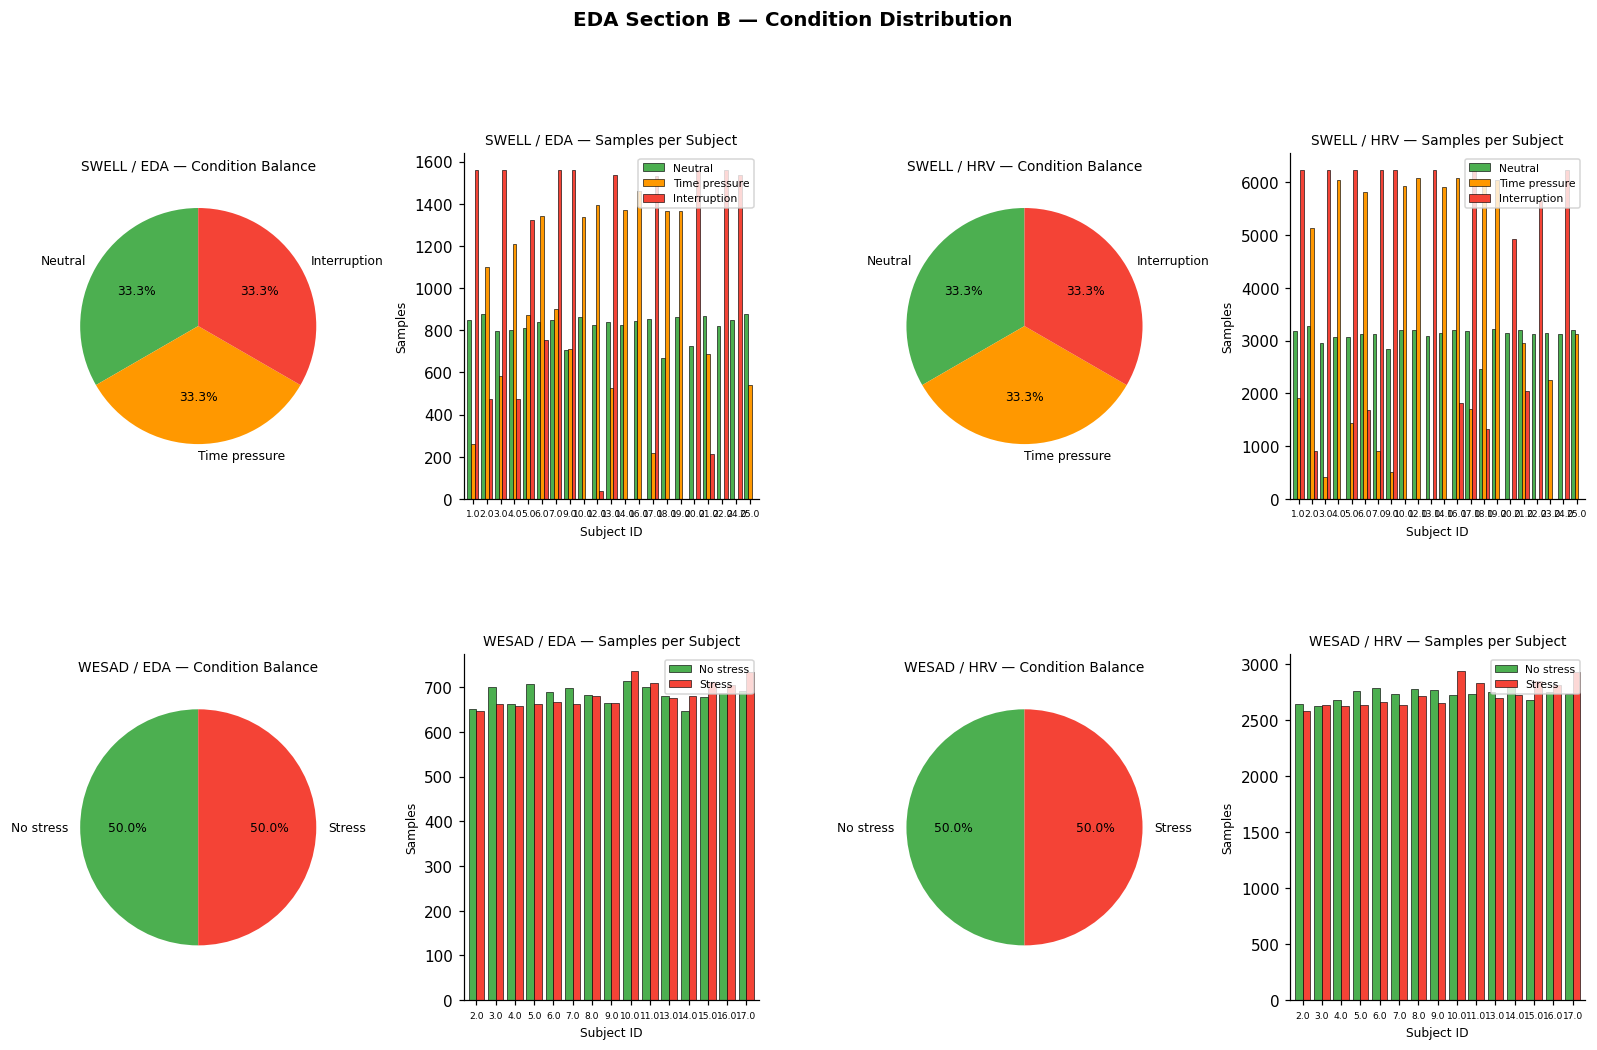

✓ EDA Section B plots complete


In [7]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, wspace=0.4, hspace=0.45)

# SWELL condition palette
SWELL_CLR = {0: "#4CAF50", 1: "#FF9800", 2: "#F44336"}
WESAD_CLR = {0: "#4CAF50", 1: "#F44336"}

plot_idx = 0
for row, ds in enumerate(DATASETS):
    for col, sig in enumerate(SIGNALS):
        df = DATA[ds][sig]["all"]
        if df is None:
            continue
        cond_col = "condition"
        clr_map  = SWELL_CLR if ds == "swell" else WESAD_CLR
        labels   = CONDITION_LABELS[ds]

        # B1 — Pie chart (overall)
        ax_pie = fig.add_subplot(gs[row, col * 2])
        counts  = df[cond_col].value_counts().sort_index()
        pie_lbl = [labels[int(c)] for c in counts.index]
        pie_clr = [clr_map[int(c)] for c in counts.index]
        ax_pie.pie(counts.values, labels=pie_lbl, colors=pie_clr,
                   autopct="%1.1f%%", startangle=90, textprops={"fontsize": 8})
        ax_pie.set_title(f"{ds.upper()} / {sig.upper()} — Condition Balance", fontsize=9)

        # B2 — Per-subject condition sample bar
        ax_bar = fig.add_subplot(gs[row, col * 2 + 1])
        sid_col = SUBJ_COL[ds]
        pivot   = df.groupby([sid_col, cond_col]).size().unstack(fill_value=0)
        pivot.columns = [labels[int(c)] for c in pivot.columns]
        bar_colors = [clr_map[int(c)] for c in df[cond_col].value_counts().sort_index().index]
        pivot.plot(kind="bar", ax=ax_bar, color=bar_colors, edgecolor="black",
                   linewidth=0.4, rot=0, legend=False, width=0.8)
        ax_bar.set_xlabel("Subject ID", fontsize=8)
        ax_bar.set_ylabel("Samples", fontsize=8)
        ax_bar.set_title(f"{ds.upper()} / {sig.upper()} — Samples per Subject", fontsize=9)
        ax_bar.tick_params(axis="x", labelsize=6)
        ax_bar.legend(fontsize=7, loc="upper right")

plt.suptitle("EDA Section B — Condition Distribution", fontsize=13, fontweight="bold", y=1.01)
plt.show()

print("✓ EDA Section B plots complete")

## EDA Section C — Regression Target Analysis (NasaTLX & SSSQ)

- **NasaTLX** (NASA Task Load Index): subjective cognitive workload rated 0–100. Higher = more stressed
- **SSSQ** (Stress Self-Questionnaire): standardized self-report measure, higher = more stressed

These are the **continuous regression targets** — separate from the categorical condition labels.

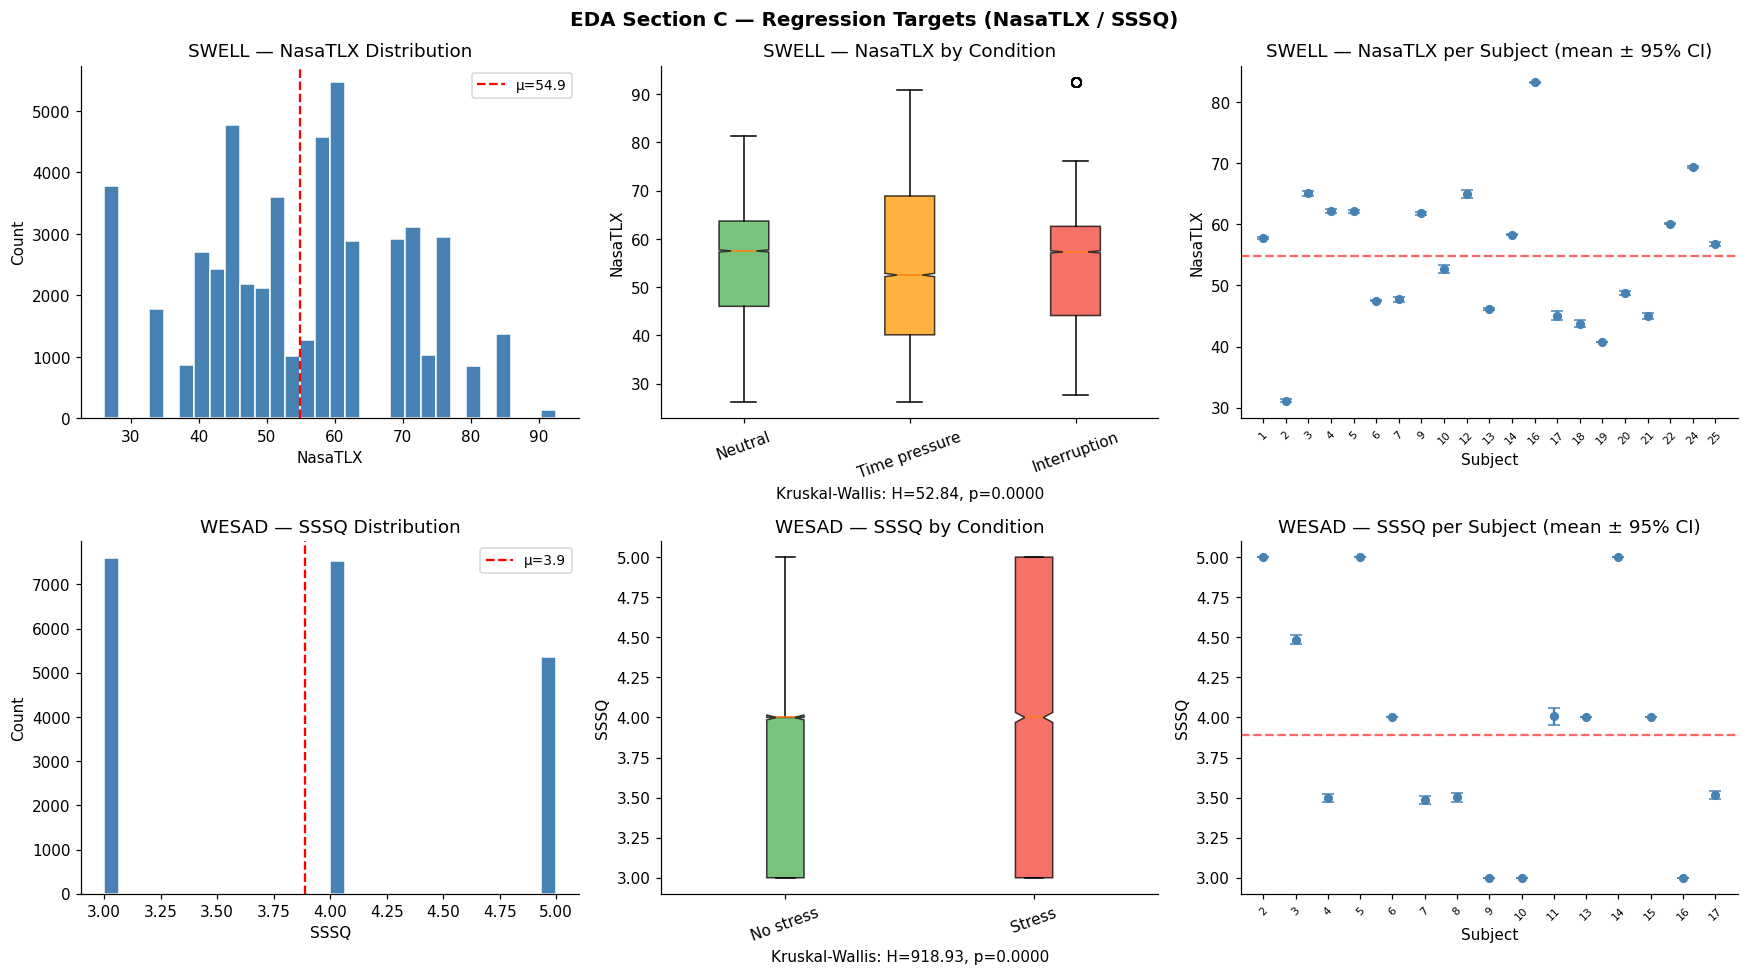

C — Regression Target Summary:

  SWELL — NasaTLX:
    Overall: mean=54.85, std=14.62, range=[26.1, 92.6]
    Condition 0 (Neutral         ): mean=55.38, std=13.53
    Condition 1 (Time pressure   ): mean=54.90, std=15.95
    Condition 2 (Interruption    ): mean=54.28, std=14.25

  WESAD — SSSQ:
    Overall: mean=3.89, std=0.79, range=[3.0, 5.0]
    Condition 0 (No stress       ): mean=3.73, std=0.77
    Condition 1 (Stress          ): mean=4.06, std=0.77

✓ EDA Section C complete


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("EDA Section C — Regression Targets (NasaTLX / SSSQ)",
             fontsize=13, fontweight="bold")

for row, ds in enumerate(DATASETS):
    reg_col  = REG_TARGET[ds]
    cond_col = "condition"
    clr_map  = SWELL_CLR if ds == "swell" else WESAD_CLR
    labels   = CONDITION_LABELS[ds]

    # Use EDA signal (typically smaller file)
    df = DATA[ds]["eda"]["all"]
    if df is None or reg_col not in df.columns:
        continue

    # C1 — Histogram of regression target
    axes[row, 0].hist(df[reg_col].dropna(), bins=30, color="steelblue", edgecolor="white")
    axes[row, 0].set_xlabel(reg_col)
    axes[row, 0].set_ylabel("Count")
    axes[row, 0].set_title(f"{ds.upper()} — {reg_col} Distribution")
    axes[row, 0].axvline(df[reg_col].mean(), color="red", linestyle="--",
                          label=f"μ={df[reg_col].mean():.1f}")
    axes[row, 0].legend(fontsize=9)

    # C2 — Regression target by condition (boxplot)
    groups  = [df[df[cond_col] == c][reg_col].dropna().values for c in sorted(df[cond_col].unique())]
    grp_lbl = [labels[int(c)] for c in sorted(df[cond_col].unique())]
    bp = axes[row, 1].boxplot(groups, patch_artist=True,
                               notch=True, labels=grp_lbl)
    for patch, c in zip(bp["boxes"], sorted(df[cond_col].unique())):
        patch.set_facecolor(clr_map[int(c)]); patch.set_alpha(0.75)
    axes[row, 1].set_ylabel(reg_col)
    axes[row, 1].set_title(f"{ds.upper()} — {reg_col} by Condition")
    axes[row, 1].tick_params(axis="x", rotation=20)

    # Kruskal-Wallis test (non-parametric ANOVA)
    stat, pval = kruskal(*groups)
    axes[row, 1].set_xlabel(f"Kruskal-Wallis: H={stat:.2f}, p={pval:.4f}")

    # C3 — Per-subject regression target mean + CI
    sid_col  = SUBJ_COL[ds]
    subj_reg = df.groupby(sid_col)[reg_col].agg(["mean", "sem"]).reset_index()
    axes[row, 2].errorbar(range(len(subj_reg)), subj_reg["mean"],
                           yerr=subj_reg["sem"] * 1.96,
                           fmt="o", color="steelblue", capsize=4, markersize=5)
    axes[row, 2].axhline(df[reg_col].mean(), color="red", linestyle="--", alpha=0.6)
    axes[row, 2].set_xticks(range(len(subj_reg)))
    axes[row, 2].set_xticklabels(subj_reg[sid_col].astype(int), fontsize=7, rotation=45)
    axes[row, 2].set_ylabel(reg_col)
    axes[row, 2].set_xlabel("Subject")
    axes[row, 2].set_title(f"{ds.upper()} — {reg_col} per Subject (mean ± 95% CI)")

plt.tight_layout()
plt.show()

# ── Print regression target statistics ─────────────────────────────────────────
print("C — Regression Target Summary:")
for ds in DATASETS:
    reg_col = REG_TARGET[ds]
    df = DATA[ds]["eda"]["all"]
    if df is None or reg_col not in df.columns:
        continue
    cond_col = "condition"
    print(f"\n  {ds.upper()} — {reg_col}:")
    print(f"    Overall: mean={df[reg_col].mean():.2f}, std={df[reg_col].std():.2f}, "
          f"range=[{df[reg_col].min():.1f}, {df[reg_col].max():.1f}]")
    for cond in sorted(df[cond_col].unique()):
        vals = df[df[cond_col] == cond][reg_col]
        label = CONDITION_LABELS[ds].get(int(cond), str(cond))
        print(f"    Condition {cond:.0f} ({label:<16}): mean={vals.mean():.2f}, std={vals.std():.2f}")

print("\n✓ EDA Section C complete")

## EDA Section D — EDA Signal Feature Analysis

### Key EDA Feature Groups
| Feature | Meaning |
|---|---|
| `MEAN`, `MAX`, `MIN`, `RANGE` | Basic amplitude statistics of skin conductance |
| `KURT`, `SKEW` | Shape of distribution — stress causes skewed, peaky signals |
| `MEAN_1ST_GRAD`, `STD_1ST_GRAD` | Rate of change — how fast conductance rises/falls |
| `ALSC` | Arc-length of signal — total path length (activity measure) |
| `INSC` | Integral of absolute signal — cumulative energy |
| `APSC` | Area of positive slopes — phasic arousal events |
| `RMSC` | Root mean square — overall signal power |
| `MIN/MAX_PEAKS`, `MEAN_PEAKS` | SCR (Skin Conductance Response) peak statistics |
| `MIN/MAX_ONSET`, `MEAN_ONSET` | SCR onset latency — delayed peaks suggest relaxation |
| `*_LOG`, `*_SQRT`, `*_YEO_JON` | Transformed versions for normality |

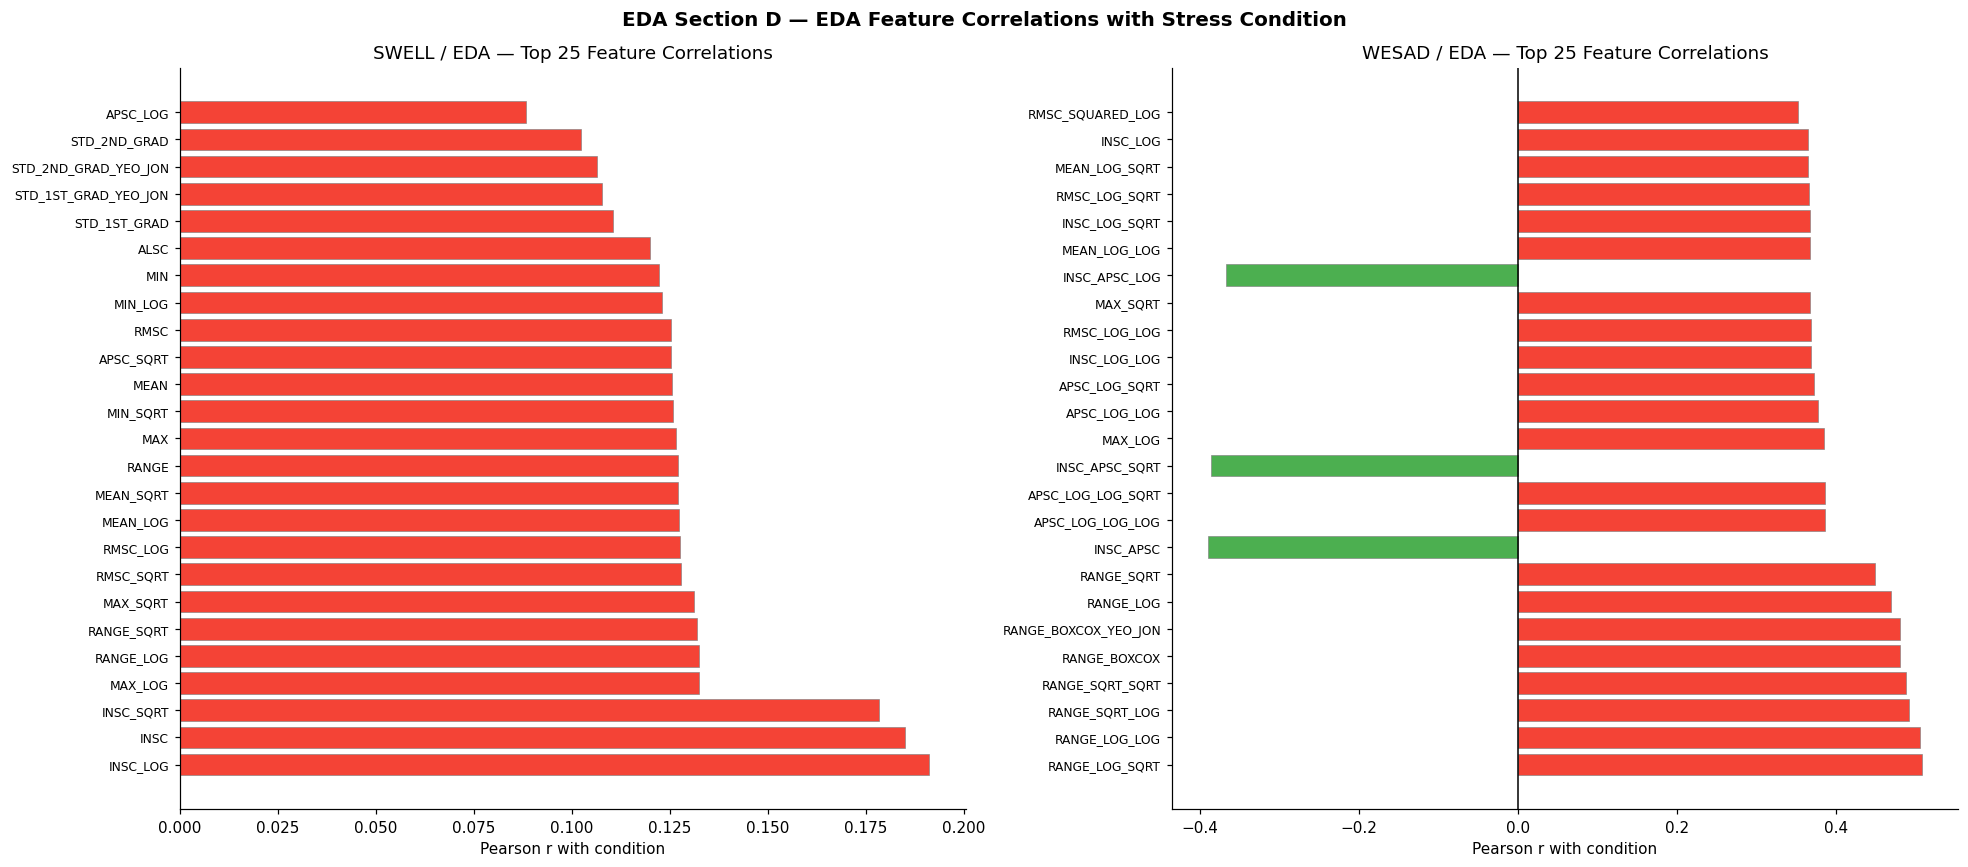

✓ EDA Section D-1 complete


In [9]:
# ── D-1: Correlation of EDA features with condition label ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("EDA Section D — EDA Feature Correlations with Stress Condition",
             fontsize=13, fontweight="bold")

for ax, ds in zip(axes, DATASETS):
    df = DATA[ds]["eda"]["all"]
    if df is None:
        ax.set_visible(False)
        continue
    feat_cols = FEAT_COLS[ds]["eda"]
    corr = df[feat_cols + ["condition"]].corr()["condition"].drop("condition")
    top_corr = corr.abs().sort_values(ascending=False).head(25)
    vals     = corr[top_corr.index]
    colors   = ["#F44336" if v > 0 else "#4CAF50" for v in vals.values]
    ax.barh(range(len(vals)), vals.values, color=colors, edgecolor="grey", linewidth=0.4)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(vals.index, fontsize=8)
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel("Pearson r with condition")
    ax.set_title(f"{ds.upper()} / EDA — Top 25 Feature Correlations")

plt.tight_layout()
plt.show()
print("✓ EDA Section D-1 complete")

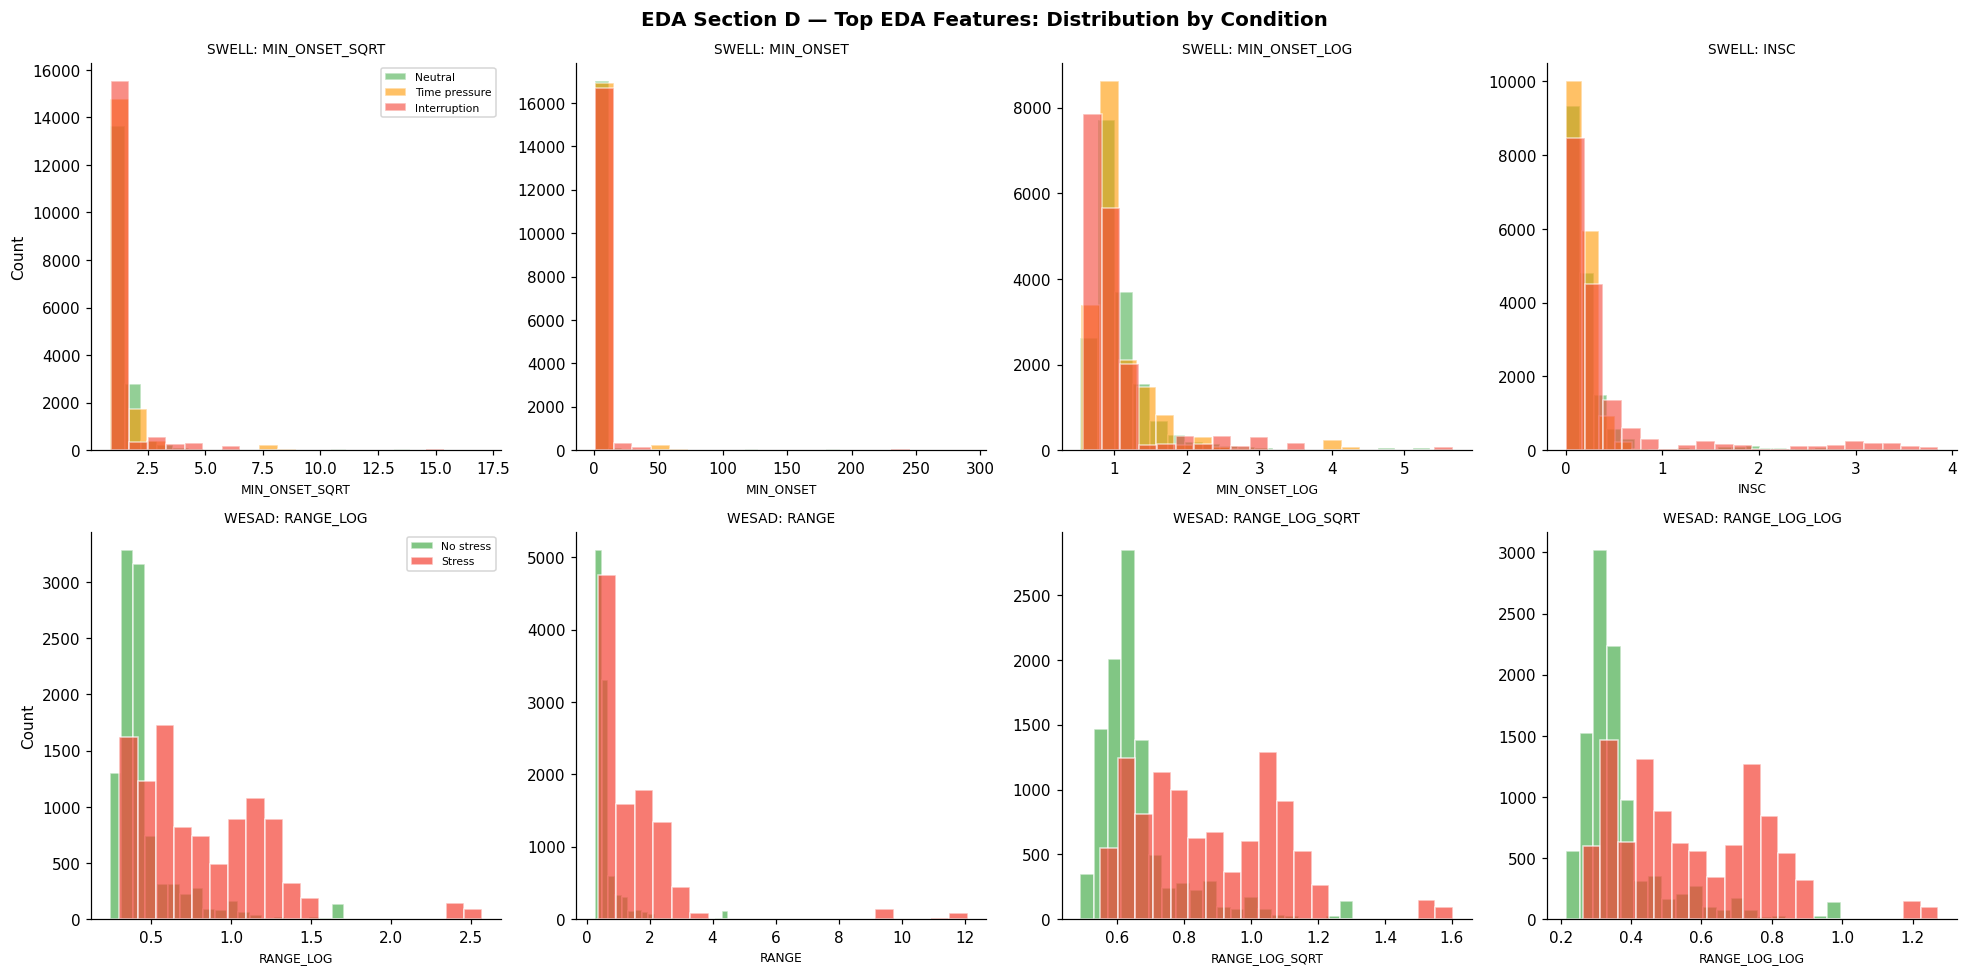

✓ EDA Section D-2 complete


In [10]:
# ── D-2: Most discriminative EDA features — distribution by condition ─────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("EDA Section D — Top EDA Features: Distribution by Condition",
             fontsize=13, fontweight="bold")

TOP_SWELL_EDA = ["MIN_ONSET_SQRT", "MIN_ONSET", "MIN_ONSET_LOG", "INSC"]
TOP_WESAD_EDA = ["RANGE_LOG",      "RANGE",     "RANGE_LOG_SQRT", "RANGE_LOG_LOG"]

for col_i, feat in enumerate(TOP_SWELL_EDA):
    df = DATA["swell"]["eda"]["all"]
    if df is None or feat not in df.columns:
        continue
    for cond in sorted(df["condition"].unique()):
        vals = df[df["condition"] == cond][feat]
        axes[0, col_i].hist(vals, bins=20, alpha=0.6,
                             color=SWELL_CLR[int(cond)], edgecolor="white",
                             label=CONDITION_LABELS["swell"][int(cond)])
    axes[0, col_i].set_title(f"SWELL: {feat}", fontsize=9)
    axes[0, col_i].set_xlabel(feat, fontsize=8)
    if col_i == 0:
        axes[0, col_i].set_ylabel("Count")
        axes[0, col_i].legend(fontsize=7)

for col_i, feat in enumerate(TOP_WESAD_EDA):
    df = DATA["wesad"]["eda"]["all"]
    if df is None or feat not in df.columns:
        continue
    for cond in sorted(df["condition"].unique()):
        vals = df[df["condition"] == cond][feat]
        axes[1, col_i].hist(vals, bins=20, alpha=0.7,
                             color=WESAD_CLR[int(cond)], edgecolor="white",
                             label=CONDITION_LABELS["wesad"][int(cond)])
    axes[1, col_i].set_title(f"WESAD: {feat}", fontsize=9)
    axes[1, col_i].set_xlabel(feat, fontsize=8)
    if col_i == 0:
        axes[1, col_i].set_ylabel("Count")
        axes[1, col_i].legend(fontsize=7)

plt.tight_layout()
plt.show()
print("✓ EDA Section D-2 complete")

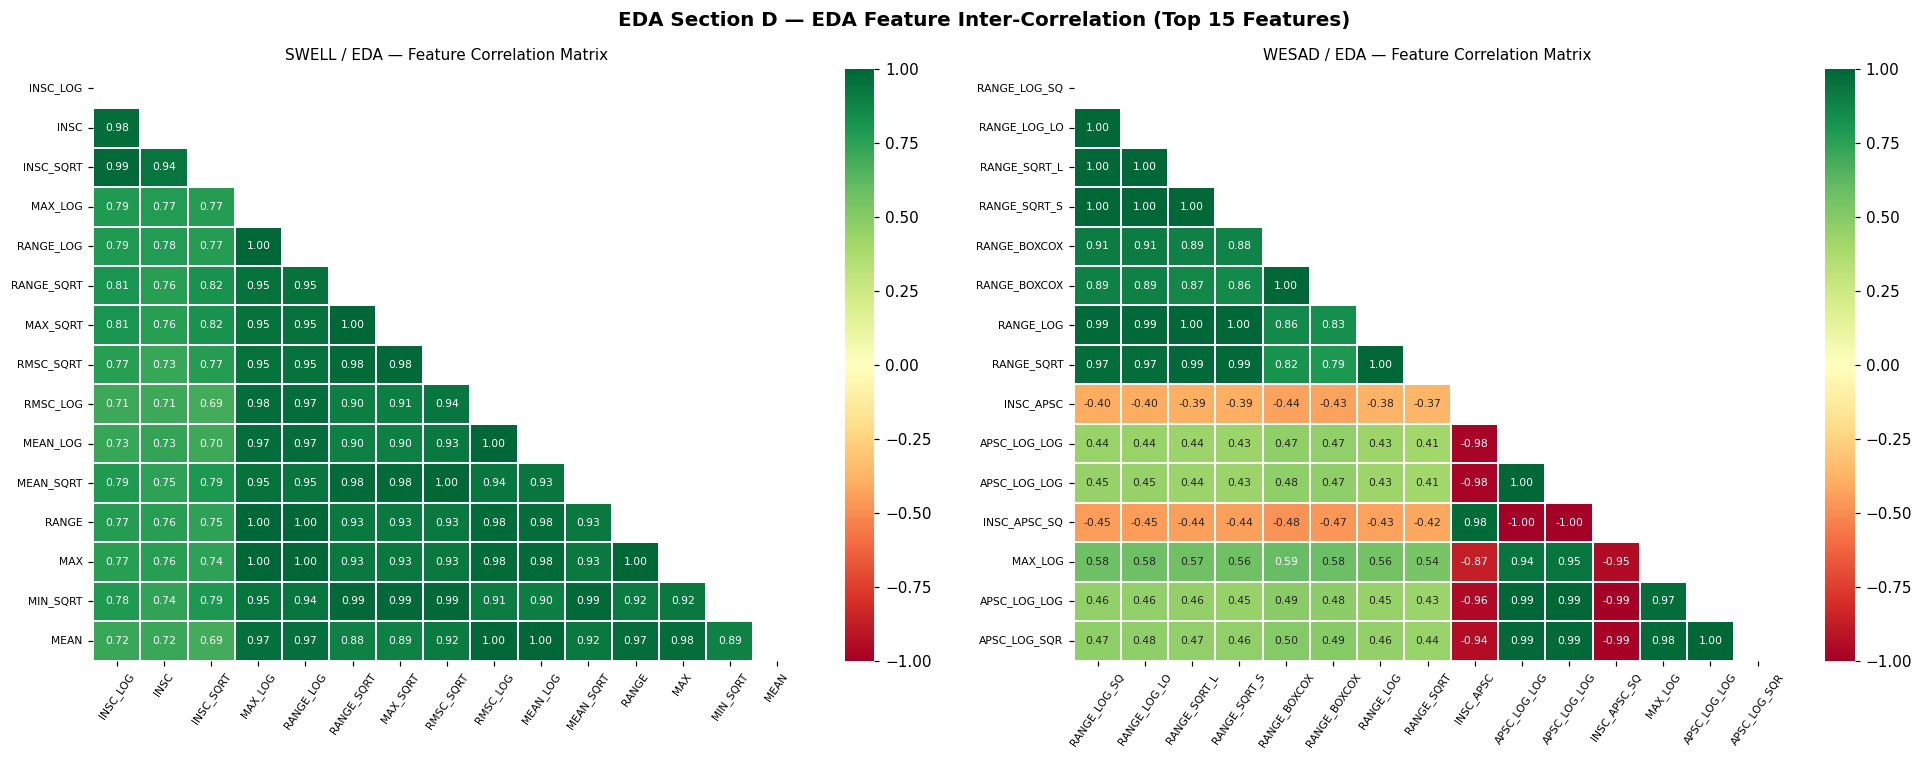

✓ EDA Section D-3 complete


In [11]:
# ── D-3: EDA feature correlation heatmap (top 15 features) ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("EDA Section D — EDA Feature Inter-Correlation (Top 15 Features)",
             fontsize=13, fontweight="bold")

for ax, ds in zip(axes, DATASETS):
    df = DATA[ds]["eda"]["all"]
    if df is None:
        continue
    feat_cols = FEAT_COLS[ds]["eda"]
    corr_w_label = df[feat_cols + ["condition"]].corr()["condition"].drop("condition")
    top15  = corr_w_label.abs().sort_values(ascending=False).head(15).index.tolist()
    cm     = df[top15].corr()
    mask   = np.triu(np.ones_like(cm, dtype=bool))
    sns.heatmap(cm, ax=ax, mask=mask, cmap="RdYlGn", center=0,
                annot=True, fmt=".2f", annot_kws={"size": 7},
                linewidths=0.3, vmin=-1, vmax=1,
                xticklabels=[c[:12] for c in top15],
                yticklabels=[c[:12] for c in top15])
    ax.set_title(f"{ds.upper()} / EDA — Feature Correlation Matrix", fontsize=10)
    ax.tick_params(axis="x", rotation=55, labelsize=7)
    ax.tick_params(axis="y", rotation=0,  labelsize=7)

plt.tight_layout()
plt.show()
print("✓ EDA Section D-3 complete")

## EDA Section E — Subject-Level Variability Analysis

Person-independent stress detection is hard because **physiological baselines vary hugely between subjects**.  
LOSO CV is used exactly to measure how well a model generalizes across this person-to-person variability.

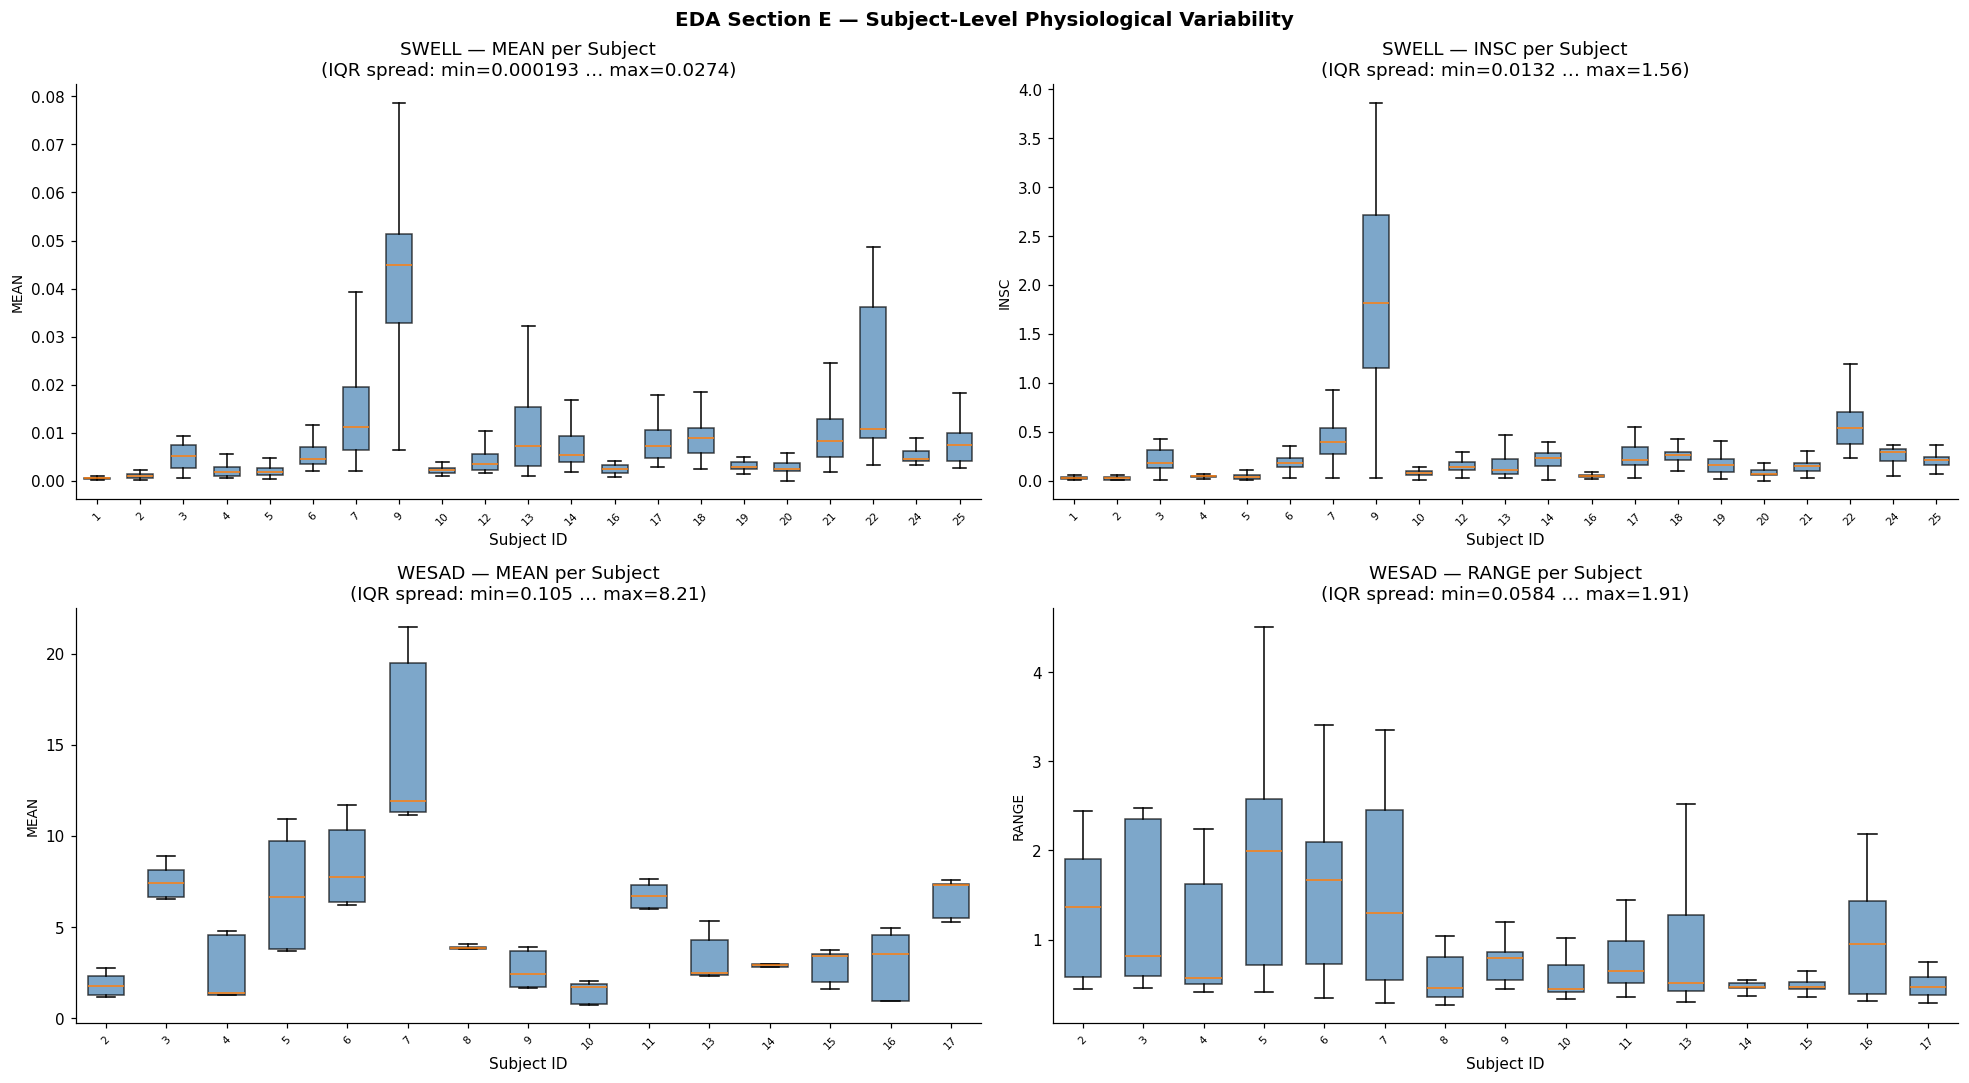

E — Inter-subject coefficient of variation (MEAN feature, EDA):
  SWELL: CV=114.1%  (higher → harder for generic models)
  WESAD: CV=71.7%  (higher → harder for generic models)

✓ EDA Section E complete


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle("EDA Section E — Subject-Level Physiological Variability",
             fontsize=13, fontweight="bold")

ANCHOR_FEATS = {
    "swell": ["MEAN", "INSC"],
    "wesad": ["MEAN", "RANGE"],
}

for row, ds in enumerate(DATASETS):
    sid_col = SUBJ_COL[ds]
    feats   = ANCHOR_FEATS[ds]

    for col_i, feat in enumerate(feats):
        df = DATA[ds]["eda"]["all"]
        if df is None or feat not in df.columns:
            continue
        ax = axes[row, col_i]

        # Box per subject
        subj_ids = sorted(df[sid_col].unique())
        data_per_subj = [df[df[sid_col] == sid][feat].dropna().values for sid in subj_ids]
        bp = ax.boxplot(data_per_subj, patch_artist=True, notch=False,
                         widths=0.6, showfliers=False)
        # Color boxes by condition median
        for patch in bp["boxes"]:
            patch.set_facecolor("steelblue"); patch.set_alpha(0.7)
        ax.set_xticks(range(1, len(subj_ids) + 1))
        ax.set_xticklabels([str(int(s)) for s in subj_ids], fontsize=7, rotation=45)
        ax.set_ylabel(feat, fontsize=9)
        ax.set_xlabel("Subject ID")
        ax.set_title(f"{ds.upper()} — {feat} per Subject (variability view)")

        # Annotate inter-quartile range spread
        ranges = [np.percentile(d, 75) - np.percentile(d, 25) if len(d) > 1 else 0
                  for d in data_per_subj]
        ax.set_title(
            f"{ds.upper()} — {feat} per Subject\n"
            f"(IQR spread: min={min(ranges):.3g} … max={max(ranges):.3g})"
        )

plt.tight_layout()
plt.show()

print("E — Inter-subject coefficient of variation (MEAN feature, EDA):")
for ds in DATASETS:
    df      = DATA[ds]["eda"]["all"]
    sid_col = SUBJ_COL[ds]
    if df is None:
        continue
    subj_means = df.groupby(sid_col)["MEAN"].mean()
    cv = subj_means.std() / subj_means.mean() * 100
    print(f"  {ds.upper()}: CV={cv:.1f}%  (higher → harder for generic models)")

print("\n✓ EDA Section E complete")

## EDA Section F — Pre-Computed Feature Rankings

The paper pre-computed feature importance rankings using RandomForest on each dataset×signal combination.  
These are stored in `results/feature-ranks/` and are the **gold standard** for feature selection.

In [13]:
# ── Load all feature rank files ────────────────────────────────────────────────
RANKS = {}   # RANKS[(ds, sig, model_type)] = list of top feature names

for sig in SIGNALS:
    for model_type in ["classification", "regression"]:
        for ds in DATASETS:
            rank_path = os.path.join(RANKS_DIR, sig, model_type, ds, "features-ranks.csv")
            try:
                rank_df = pd.read_csv(rank_path, index_col=0)
                feat_list = rank_df.index.tolist()
                top_n = TOP_N_FEATS.get((ds, sig), 50)
                RANKS[(ds, sig, model_type)] = feat_list[:top_n]
                print(f"  ✓ {ds}/{sig}/{model_type}: {len(feat_list)} ranked, top {top_n} selected")
            except Exception as e:
                print(f"  ✗ {ds}/{sig}/{model_type}: {e}")
                RANKS[(ds, sig, model_type)] = []

print("\nTop 10 features per combination:")
for key, feats in RANKS.items():
    ds, sig, mt = key
    print(f"\n  {ds.upper()}/{sig.upper()}/{mt}:")
    for i, f in enumerate(feats[:10], 1):
        print(f"    {i:>2}. {f}")

  ✓ swell/eda/classification: 58 ranked, top 46 selected
  ✓ wesad/eda/classification: 103 ranked, top 45 selected
  ✓ swell/eda/regression: 58 ranked, top 46 selected
  ✓ wesad/eda/regression: 103 ranked, top 45 selected
  ✓ swell/hrv/classification: 94 ranked, top 75 selected
  ✓ wesad/hrv/classification: 155 ranked, top 40 selected
  ✓ swell/hrv/regression: 94 ranked, top 75 selected
  ✓ wesad/hrv/regression: 155 ranked, top 40 selected

Top 10 features per combination:

  SWELL/EDA/classification:
     1. MIN_ONSET_SQRT
     2. MIN_ONSET
     3. MIN_ONSET_LOG
     4. INSC
     5. INSC_LOG
     6. INSC_SQRT
     7. MIN_PEAKS_LOG
     8. MIN_PEAKS
     9. MIN_PEAKS_SQRT
    10. MAX

  WESAD/EDA/classification:
     1. RANGE_LOG
     2. RANGE_LOG_SQRT
     3. RANGE_SQRT_LOG
     4. RANGE_LOG_LOG
     5. RANGE
     6. RANGE_SQRT
     7. RANGE_SQRT_SQRT
     8. RANGE_BOXCOX_YEO_JON
     9. RANGE_BOXCOX
    10. MIN_LOG

  SWELL/EDA/regression:
     1. MIN_PEAKS_LOG
     2. MIN_PEAKS
    

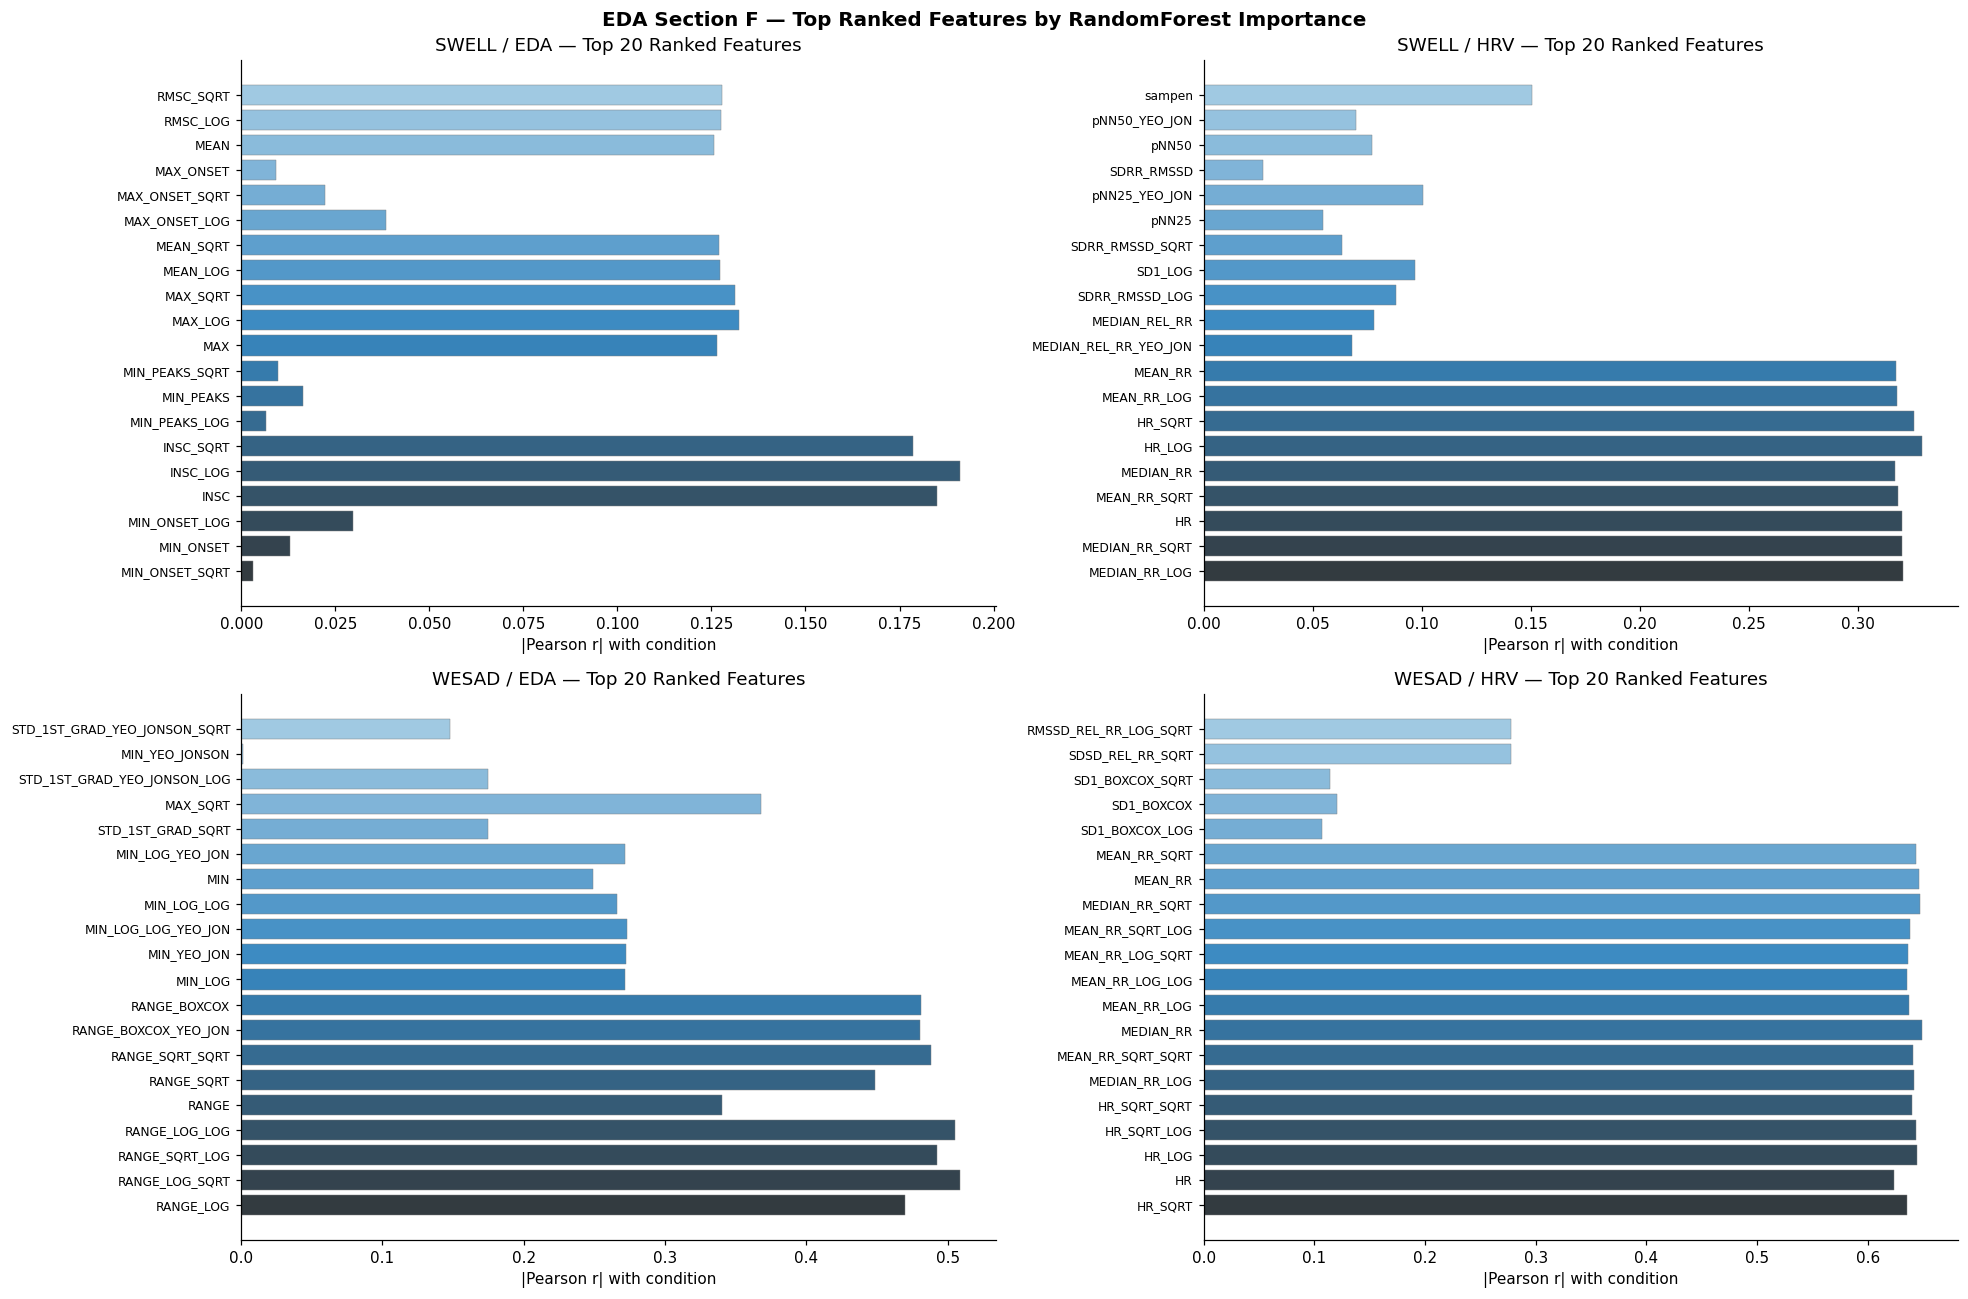

✓ EDA Section F complete


In [14]:
# ── F-2: Visualise top ranked features (classification) ─────────────────────── 
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("EDA Section F — Top Ranked Features by RandomForest Importance",
             fontsize=13, fontweight="bold")

for row, ds in enumerate(DATASETS):
    for col_i, sig in enumerate(SIGNALS):
        key   = (ds, sig, "classification")
        feats = RANKS.get(key, [])
        df    = DATA[ds][sig]["all"]
        ax    = axes[row, col_i]

        if not feats or df is None:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            continue

        # Show available features (may not all be in df columns)
        avail = [f for f in feats[:20] if f in df.columns]
        if not avail:
            ax.text(0.5, 0.5, "Features not in columns", ha="center", va="center",
                    transform=ax.transAxes)
            continue

        corr_abs = df[avail + ["condition"]].corr()["condition"].drop("condition").abs()
        clrs = sns.color_palette("Blues_d", len(avail))[::-1]
        ax.barh(range(len(avail)), [corr_abs.get(f, 0) for f in avail],
                color=clrs, edgecolor="grey", linewidth=0.3)
        ax.set_yticks(range(len(avail)))
        ax.set_yticklabels(avail, fontsize=8)
        ax.set_xlabel("|Pearson r| with condition")
        ax.set_title(f"{ds.upper()} / {sig.upper()} — Top 20 Ranked Features")

plt.tight_layout()
plt.show()
print("✓ EDA Section F complete")

---
## Section 4 — Feature Selection & Preparation

Select the top-ranked features (from pre-computed rankings) and prepare separate feature matrices for:
- **4 combinations**: SWELL×EDA, SWELL×HRV, WESAD×EDA, WESAD×HRV
- **2 tasks**: classification (condition label) + regression (NasaTLX / SSSQ)

**Scaling:** `RobustScaler` (uses median/IQR — robust to the physiological outliers common in EDA/HRV).  
**Note:** In LOSO CV, the scaler MUST be re-fitted per fold (train split only). Here we fit on all data for demonstration — the modeling notebook handles per-fold fitting.

In [15]:
def prepare_features(dataset: str, signal: str, model_type: str) -> dict:
    """
    Select top-ranked features, assemble X matrix, encode y labels.
    Returns: {'X': ndarray, 'y': ndarray, 'subject_ids': ndarray,
               'feat_cols': list, 'scaler': RobustScaler, 'df': pd.DataFrame}
    """
    df = DATA[dataset][signal]["all"]
    if df is None:
        print(f"  ✗ {dataset}/{signal}: no data")
        return None

    # Select top features from pre-computed ranks
    key        = (dataset, signal, model_type)
    top_feats  = RANKS.get(key, [])
    avail_feat = [f for f in top_feats if f in df.columns]

    # Fallback: if no ranks, use all feature cols
    if not avail_feat:
        avail_feat = FEAT_COLS[dataset][signal]
        print(f"    ⚠ No ranks found — using all {len(avail_feat)} features")

    # Build X
    X_raw = df[avail_feat].values.astype(np.float64)

    # Handle inf / NaN
    X_raw = np.where(np.isfinite(X_raw), X_raw, np.nan)
    col_medians = np.nanmedian(X_raw, axis=0)
    nan_mask    = np.isnan(X_raw)
    X_raw[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

    # Scale with RobustScaler
    scaler = RobustScaler()
    X      = scaler.fit_transform(X_raw).astype(np.float32)

    # Build y
    sid_col = SUBJ_COL[dataset]
    if model_type == "classification":
        y = df["condition"].values.astype(np.int32)
    else:
        reg_col = REG_TARGET[dataset]
        y = df[reg_col].values.astype(np.float32) if reg_col in df.columns else None

    subject_ids = df[sid_col].values

    return {
        "X"           : X,
        "y"           : y,
        "subject_ids" : subject_ids,
        "feat_cols"   : avail_feat,
        "scaler"      : scaler,
        "df"          : df,
    }


# ── Run preparation for all combinations ──────────────────────────────────────
PREPARED = {}
print("Preparing feature matrices ...\n")
for ds in DATASETS:
    for sig in SIGNALS:
        for mt in ["classification", "regression"]:
            key    = (ds, sig, mt)
            result = prepare_features(ds, sig, mt)
            PREPARED[key] = result
            if result is not None:
                shape_y = result["y"].shape if result["y"] is not None else "N/A"
                print(f"  ✓ {ds}/{sig}/{mt}: X={result['X'].shape}, y={shape_y}, "
                      f"{len(result['feat_cols'])} features")

print("\n✓ Feature preparation complete")

Preparing feature matrices ...

  ✓ swell/eda/classification: X=(51741, 46), y=(51741,), 46 features
  ✓ swell/eda/regression: X=(51741, 46), y=(51741,), 46 features
  ✓ swell/hrv/classification: X=(204885, 75), y=(204885,), 75 features
  ✓ swell/hrv/regression: X=(204885, 75), y=(204885,), 75 features
  ✓ wesad/eda/classification: X=(20496, 45), y=(20496,), 45 features
  ✓ wesad/eda/regression: X=(20496, 45), y=(20496,), 45 features
  ✓ wesad/hrv/classification: X=(81892, 40), y=(81892,), 40 features
  ✓ wesad/hrv/regression: X=(81892, 40), y=(81892,), 40 features

✓ Feature preparation complete


## Section 5 — Feature Matrix Inspection

  STRESS — Final Feature Matrix Summary
  Dataset  Signal Task              Samples  Features  Subjects
--------------------------------------------------------------------
  swell    eda    classification     51,741        46        21
  swell    eda    regression         51,741        46        21
  swell    hrv    classification    204,885        75        22
  swell    hrv    regression        204,885        75        22
  wesad    eda    classification     20,496        45        15
  wesad    eda    regression         20,496        45        15
  wesad    hrv    classification     81,892        40        15
  wesad    hrv    regression         81,892        40        15


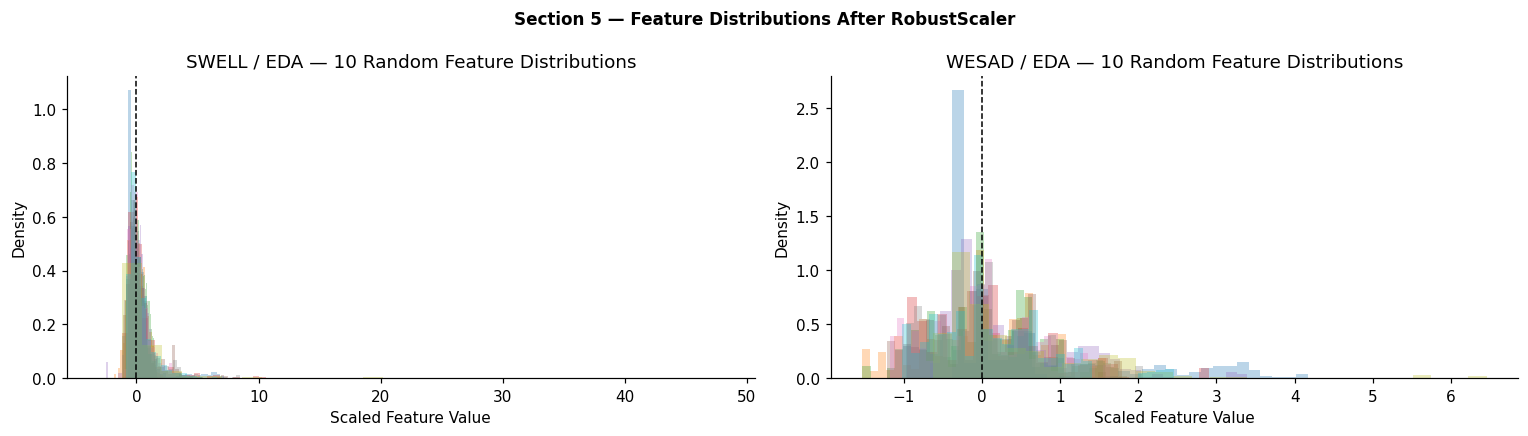


✓ Section 5 complete


In [16]:
print("=" * 68)
print("  STRESS — Final Feature Matrix Summary")
print("=" * 68)
print(f"  {'Dataset':<8} {'Signal':<6} {'Task':<16} {'Samples':>8} {'Features':>9} {'Subjects':>9}")
print("-" * 68)

for (ds, sig, mt), result in PREPARED.items():
    if result is None:
        print(f"  {ds:<8} {sig:<6} {mt:<16} {'N/A':>8}")
        continue
    n_subj = len(np.unique(result["subject_ids"]))
    print(f"  {ds:<8} {sig:<6} {mt:<16} {result['X'].shape[0]:>8,} "
          f"{result['X'].shape[1]:>9} {n_subj:>9}")

print("=" * 68)

# ── Scaled feature distribution check ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Section 5 — Feature Distributions After RobustScaler",
             fontsize=11, fontweight="bold")

for ax, ds in zip(axes, DATASETS):
    result = PREPARED.get((ds, "eda", "classification"))
    if result is None:
        continue
    X     = result["X"]
    # Sample 10 random feature columns
    feat_sample = np.random.choice(X.shape[1], min(10, X.shape[1]), replace=False)
    for fi in feat_sample:
        ax.hist(X[:, fi], bins=30, alpha=0.3, density=True)
    ax.set_xlabel("Scaled Feature Value")
    ax.set_ylabel("Density")
    ax.set_title(f"{ds.upper()} / EDA — 10 Random Feature Distributions")
    ax.axvline(0, color="black", lw=1, linestyle="--")

plt.tight_layout()
plt.show()
print("\n✓ Section 5 complete")

## Section 6 — Save All Prepared Data

In [17]:
import os as _os

saved_files = []

for (ds, sig, mt), result in PREPARED.items():
    if result is None:
        continue

    tag = f"stress_{ds}_{sig}_{mt[:5]}"

    # ── Feature matrix X ──────────────────────────────────────────────────────
    x_path = os.path.join(OUT_DIR, f"{tag}_X.npy")
    np.save(x_path, result["X"])
    saved_files.append((x_path, f"X {result['X'].shape} float32"))

    # ── Labels y ──────────────────────────────────────────────────────────────
    if result["y"] is not None:
        y_path = os.path.join(OUT_DIR, f"{tag}_y.npy")
        np.save(y_path, result["y"])
        saved_files.append((y_path, f"y {result['y'].shape}"))

    # ── Subject IDs ───────────────────────────────────────────────────────────
    sid_path = os.path.join(OUT_DIR, f"{tag}_subject_ids.npy")
    np.save(sid_path, result["subject_ids"])
    saved_files.append((sid_path, "subject IDs for LOSO CV"))

    # ── Feature column names ──────────────────────────────────────────────────
    cols_path = os.path.join(OUT_DIR, f"{tag}_feature_cols.txt")
    with open(cols_path, "w") as f:
        f.write("\n".join(result["feat_cols"]))
    saved_files.append((cols_path, f"{len(result['feat_cols'])} feature names"))

    # ── Scaler ────────────────────────────────────────────────────────────────
    scaler_path = os.path.join(OUT_DIR, f"{tag}_scaler.pkl")
    with open(scaler_path, "wb") as f:
        pickle.dump(result["scaler"], f)
    saved_files.append((scaler_path, "RobustScaler (demonstration only — refit per LOSO fold)"))

# ── Full feature CSVs (for EDA) ───────────────────────────────────────────────
for ds in DATASETS:
    for sig in SIGNALS:
        df = DATA[ds][sig]["all"]
        if df is None:
            continue
        csv_path = os.path.join(OUT_DIR, f"stress_{ds}_{sig}_full.csv")
        df.drop(columns=["_split"], errors="ignore").to_csv(csv_path, index=False, float_format="%.6f")
        saved_files.append((csv_path, f"{df.shape} full data"))

# ── Feature rank map (JSON) ────────────────────────────────────────────────────
ranks_json = {f"{ds}_{sig}_{mt}": feats
              for (ds, sig, mt), feats in RANKS.items()}
json_path  = os.path.join(OUT_DIR, "stress_feature_ranks.json")
with open(json_path, "w") as f:
    json.dump(ranks_json, f, indent=2)
saved_files.append((json_path, "feature rankings all combinations"))

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 70)
print("  Stress Dataset — Saved Files")
print("=" * 70)
for fpath, desc in saved_files:
    exists = "✓" if _os.path.exists(fpath) else "✗"
    size   = f"{_os.path.getsize(fpath)/1024:.1f} KB" if _os.path.exists(fpath) else "N/A"
    fname  = _os.path.basename(fpath)
    print(f"  {exists}  {fname:<50} {size:<10}  {desc}")

print(f"\n  Total files saved: {len(saved_files)}")
print("✓ All stress data saved to processed_data/stress/")

  Stress Dataset — Saved Files
  ✓  stress_swell_eda_class_X.npy                       9297.3 KB   X (51741, 46) float32
  ✓  stress_swell_eda_class_y.npy                       202.2 KB    y (51741,)
  ✓  stress_swell_eda_class_subject_ids.npy             404.4 KB    subject IDs for LOSO CV
  ✓  stress_swell_eda_class_feature_cols.txt            0.5 KB      46 feature names
  ✓  stress_swell_eda_class_scaler.pkl                  1.1 KB      RobustScaler (demonstration only — refit per LOSO fold)
  ✓  stress_swell_eda_regre_X.npy                       9297.3 KB   X (51741, 46) float32
  ✓  stress_swell_eda_regre_y.npy                       202.2 KB    y (51741,)
  ✓  stress_swell_eda_regre_subject_ids.npy             404.4 KB    subject IDs for LOSO CV
  ✓  stress_swell_eda_regre_feature_cols.txt            0.5 KB      46 feature names
  ✓  stress_swell_eda_regre_scaler.pkl                  1.1 KB      RobustScaler (demonstration only — refit per LOSO fold)
  ✓  stress_swell_hrv_class_X

## Section 7 — Reload Snippet & Modeling Guide

### Load data in modeling notebook

```python
import numpy as np, json, pickle

# Load EDA classification data for SWELL
X    = np.load("processed_data/stress/stress_swell_eda_class_X.npy")
y    = np.load("processed_data/stress/stress_swell_eda_class_y.npy")          # 0/1/2
sids = np.load("processed_data/stress/stress_swell_eda_class_subject_ids.npy")

with open("processed_data/stress/stress_swell_eda_class_feature_cols.txt") as f:
    feat_cols = f.read().splitlines()

# Load all feature rankings
with open("processed_data/stress/stress_feature_ranks.json") as f:
    ranks = json.load(f)
```

### LOSO CV skeleton (correct way to use this data)

```python
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import f1_score

unique_subjects = np.unique(sids)
all_preds, all_true = [], []

for test_subj in unique_subjects:
    train_mask = sids != test_subj
    test_mask  = sids == test_subj

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    # ⚠️ ALWAYS refit scaler on train only inside each fold
    scaler  = RobustScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test  = scaler.transform(X_test)

    model = ExtraTreesClassifier(n_estimators=500, class_weight="balanced",
                                  max_depth=16, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    all_preds.extend(preds)
    all_true.extend(y_test)

print(f"LOSO F1 (weighted): {f1_score(all_true, all_preds, average='weighted'):.3f}")
```

### Data combinations available

| File prefix | Dataset | Signal | Task |
|---|---|---|---|
| `stress_swell_eda_class_*` | SWELL | EDA | 3-class stress detection |
| `stress_swell_eda_regre_*` | SWELL | EDA | NasaTLX regression |
| `stress_swell_hrv_class_*` | SWELL | HRV | 3-class stress detection |
| `stress_swell_hrv_regre_*` | SWELL | HRV | NasaTLX regression |
| `stress_wesad_eda_class_*` | WESAD | EDA | Binary stress detection |
| `stress_wesad_eda_regre_*` | WESAD | EDA | SSSQ regression |
| `stress_wesad_hrv_class_*` | WESAD | HRV | Binary stress detection |
| `stress_wesad_hrv_regre_*` | WESAD | HRV | SSSQ regression |